# Fine-Tuning de CycleGAN — León ↔ Guepardo

## Problema

El objetivo de este experimento es realizar **fine-tuning** sobre un modelo **CycleGAN**
pre-entrenado (horse2zebra) para aprender la traducción entre dos dominios visuales:
**leones** y **guepardos** (*cheetahs*).

CycleGAN permite aprender una transformación bidireccional entre dos dominios
sin necesidad de pares de imágenes alineadas. Partiendo del checkpoint pre-entrenado
horse2zebra, ajustaremos el modelo para que aprenda a convertir:
- León → Guepardo (y viceversa)

### Dataset

Usamos el dataset [Wildlife Animals Images](https://www.kaggle.com/datasets/anshulmehtakaggl/wildlife-animals-images)
de Kaggle. Este notebook descarga el dataset, filtra únicamente las imágenes de
**leones** y **guepardos** en resolución 300×300, y las prepara para el
entrenamiento: split 90/10 entrenamiento/prueba, resize a 256×256.

### Flujo

1. Descargar dataset desde Kaggle
2. Filtrar solo leones y guepardos en 300×300
3. Validar dimensiones reales de las imágenes
4. Dividir en 90% entrenamiento / 10% prueba
5. Redimensionar a 256×256 y exportar como PNG
6. Visualizar muestras y confirmar resultado

In [1]:
# Ejecutar el pipeline de preparacion del dataset
from src.download_and_prepare import prepare_dataset, DatasetPreparationError

try:
    summary = prepare_dataset()
    print("\nPreparacion completada exitosamente.")
except DatasetPreparationError as e:
    print(f"\nError en la preparacion del dataset: {e}")
    raise

/home/donpedromz/Documents/Artificial Intelligence/FineTunned-CycleGAN/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset downloaded to: /home/donpedromz/.cache/kagglehub/datasets/anshulmehtakaggl/wildlife-animals-images/versions/43
Total image files found: 5175

--- Stage: Class & Resolution Filter ---
  Images in lion-resize-300:  294
  Images in cheetah-resize-300: 343
  Total after class filter:             637

--- Stage: Dimension Validation ---
  Lion valid (300×300):    294
  Cheetah valid (300×300): 342
  Total after validation:  636

--- Stage: Train/Test Split (90/10, seed=42) ---
      lion: 264 train,  30 test (total 294)
   cheetah: 307 train,  35 test (total 342)

--- Stage: Resize (256×256, LANCZOS) & Export ---


/home/donpedromz/Documents/Artificial Intelligence/FineTunned-CycleGAN/src/download_and_prepare.py:158: UserWarning: cheetah/00000244_300resized.png: corrupted (cannot identify image file '/home/donpedromz/.cache/kagglehub/datasets/anshulmehtakaggl/wildlife-animals-images/versions/43/cheetah-resize-300/resize-300/00000244_300resized.png') — skipping
  warnings.warn(f"{class_name}/{p.name}: corrupted ({exc}) — skipping")


  train/lion: 264 exported, 0 errors → data/train/lion
  test/lion: 30 exported, 0 errors → data/test/lion
  train/cheetah: 307 exported, 0 errors → data/train/cheetah
  test/cheetah: 35 exported, 0 errors → data/test/cheetah

  DATASET PREPARATION — COMPLETE
  Stage                               Count   
  -------------------------------------------
  Total images downloaded             5175    
  After class filter (lion+cheetah)   637     
  After dimension validation (300×300) 636     

  Split        Lion     Cheetah  Total   
  ------------------------------------
  Train        264      307      571     
  Test         30       35       65      
  ------------------------------------
  Total        294      342      636     

  All images resized to 256×256 PNG via LANCZOS.
  Output: data/train/{lion,cheetah}/, data/test/{lion,cheetah}/

Preparacion completada exitosamente.


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

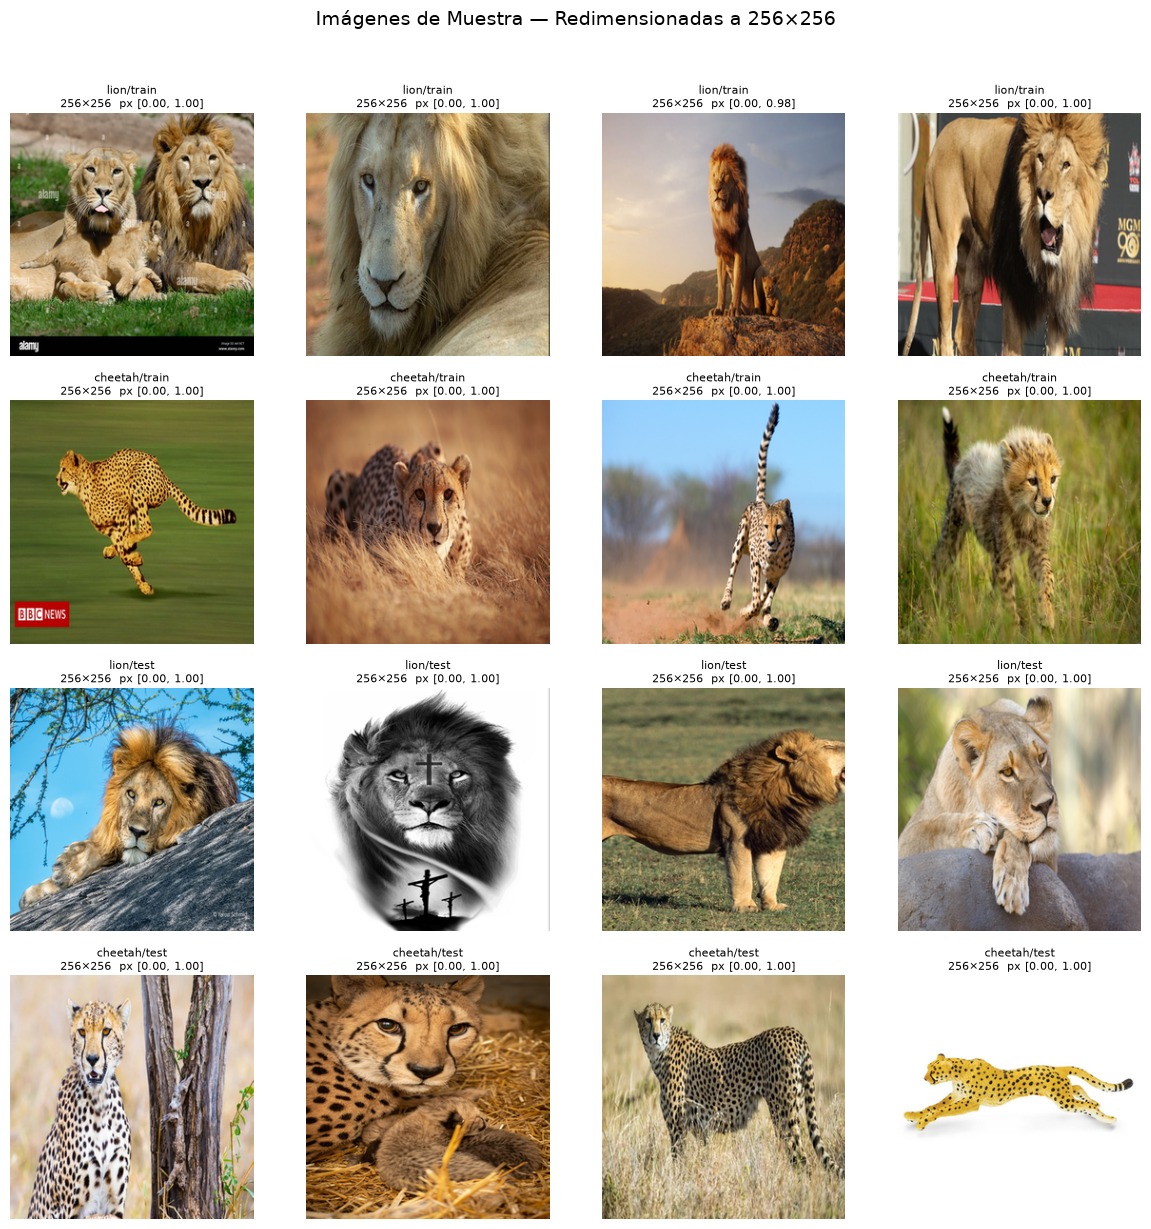

In [3]:
# ─── Mostrar imágenes de muestra: ≥4 por clase/split ───

splits = [("train", "lion"), ("train", "cheetah"), ("test", "lion"), ("test", "cheetah")]
samples_per_split = 4

fig, axes = plt.subplots(len(splits), samples_per_split,
                         figsize=(samples_per_split * 3, len(splits) * 3))

if len(splits) == 1:
    axes = [axes]

for row, (split, cls) in enumerate(splits):
    img_dir = Path("data") / split / cls
    pngs = sorted(img_dir.glob("*.png"))

    if len(pngs) == 0:
        for col in range(samples_per_split):
            ax = axes[row][col]
            ax.axis("off")
            if col == 0:
                ax.text(0.5, 0.5, f"No hay imágenes para\n{cls}/{split}",
                        ha="center", va="center", fontsize=10, color="gray")
        continue

    indices = np.linspace(0, len(pngs) - 1, samples_per_split, dtype=int)
    selected = [pngs[i] for i in indices]

    for col, png_path in enumerate(selected):
        ax = axes[row][col]
        img = mpimg.imread(png_path)
        ax.imshow(img)
        ax.axis("off")
        h, w = img.shape[:2]
        px_min, px_max = img.min(), img.max()
        ax.set_title(f"{cls}/{split}\n{h}×{w}  px [{px_min:.2f}, {px_max:.2f}]",
                     fontsize=8, pad=4)

fig.suptitle("Imágenes de Muestra — Redimensionadas a 256×256", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()